# Real-FDTD WDM MZI -- SAX Composition + Physical Layout

This notebook builds a full MZI from **genuinely FDTD-measured S-parameters** for
every piece -- the directional coupler (`notebooks/06_directional_coupler.ipynb` /
`models/coupler.py`) and the new 4-Euler-bend delay arm
(`notebooks/03_mzi_arm.ipynb` / `models/mzi_arm.py`) -- composed via `sax.circuit()`,
unlike `circuits/wdm_mux_mzi_lattice_sax.ipynb`, whose couplers were ideal/analytic.

This is only possible because `meep_sim/coupler.py` was extended to capture and
persist complex (magnitude AND phase) S-parameters -- its original artifact was
power-only, which cannot drive a genuinely interferometric circuit (an MZI's
transmission depends on the coupler's own through/cross phase relationship, not just
its power split). See `CLAUDE.md` Sec 7's "persist complex S-parameters" note.

This notebook is meep-free (pure SAX/JAX + numpy + gdsfactory for the GDS export) and
fast to run -- no new FDTD simulation. `pic_toolkit`'s existing meep-free-ness
convention: `assert "meep" not in sys.modules` is checked directly in
Section 2.

**Do not use "Run All"** for the same reason every notebook in this repo says so: stop
and look at each plot before trusting the next step.


## 1. Circuit topology

Two identical 50:50 directional couplers (`models.coupler.coupler`, the same
`coupling_length_um` design `06_directional_coupler.ipynb` selected) joined by two
arms spanning the same 26um gap:
- **Reference arm** (top): `models.waveguide.waveguide(length_um=26.0)` -- the
  existing analytic, lossless phase-only model, reused as-is.
- **Delay arm** (bottom): `models.mzi_arm.mzi_arm` -- the new real-FDTD jog geometry,
  at its baseline `delta_L_um=15.0`.

`26.0um` is not an arbitrary choice: it is `mzi_arm`'s own FIXED port-to-port span
(`2*lead_len_um + 4*radius_um` at its design-point defaults) -- the reference arm's
length is set to match it so both arms bridge the identical physical gap between the
two coupler stages (Section 5's GDS layout depends on this same match).

Both `coupler` and `mzi_arm` are used through `ml.unitary_project` (Section 2) rather
than directly -- their raw measured S-matrices are unitary only up to FDTD noise,
which is fine composing 2 of them (this section) but is not guaranteed to stay unitary
cascading 3+ (Section 9's N=4 lattice) -- see that wrapper's own docstring.


## 2. Imports and design parameters

In [1]:
import sys

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import sax

from pic_toolkit import style
from pic_toolkit.circuits import mzi_lattice as ml
from pic_toolkit.models import coupler as coupler_model
from pic_toolkit.models import mzi_arm as mzi_arm_model
from pic_toolkit.models import waveguide as waveguide_model

assert "meep" not in sys.modules, "this notebook must stay meep-free -- see its own docstring cell"

style.apply_style()
%matplotlib inline

REFERENCE_ARM_LENGTH_UM = 26.0  # matches mzi_arm's own fixed port-to-port span exactly
WL0_UM = 1.35
DELTA_L_UM = 15.0
N_EFF0, N_G0 = 2.4085, 2.763  # same values circuits/wdm_mux_mzi_lattice_sax.ipynb uses,
                              # for the ideal-model comparison curves in Sections 12-13

# Real components' own S-matrices are unitary only up to FDTD measurement noise --
# fine for N=2, but cascading 3+ of them was found to violate passivity outright
# (see ml.unitary_project's own docstring / docs/simulation_settings_record.md's
# circuits/mzi_lattice.py section for the full investigation). Wrap once, reuse for
# every real circuit built below (N=2 and N=4 alike, for a consistent comparison).
coupler_u = ml.unitary_project(coupler_model.coupler, ("in_top", "in_bot", "out_top", "out_bot"))
mzi_arm_u = ml.unitary_project(mzi_arm_model.mzi_arm, ("o1", "o2"))


/home/yuma/miniconda3/envs/mp/lib/python3.10/site-packages/sax/backends/__init__.py:78: UserWarning: klujax not found. Please install klujax for better performance during circuit evaluation!
  warnings.warn(


## 3. Sanity check: is the coupler's phase actually there now?

Before composing anything, confirm `models.coupler.coupler` returns genuine complex
values (not the old zero-phase `sqrt(power)`).

In [2]:
s_sample = coupler_model.coupler(wl=WL0_UM)
s_through = s_sample[("in_top", "out_top")]
s_cross = s_sample[("in_top", "out_bot")]
print(f"S(out_top<-in_top) = {complex(s_through):.4f}  |.|^2={abs(s_through)**2:.4f}  phase={np.angle(s_through):.4f} rad")
print(f"S(out_bot<-in_top) = {complex(s_cross):.4f}  |.|^2={abs(s_cross)**2:.4f}  phase={np.angle(s_cross):.4f} rad")
assert np.angle(s_through) != 0.0 or np.angle(s_cross) != 0.0, "coupler phase still looks like zero -- re-run 06_directional_coupler.ipynb first"
print("cross - through phase difference (rad):", np.angle(s_cross) - np.angle(s_through))
print("expected ~pi/2 (90deg) for a standard lossless 3dB coupler convention")


S(out_top<-in_top) = 0.3159-0.6281j  |.|^2=0.4943  phase=-1.1047 rad
S(out_bot<-in_top) = 0.6306+0.3193j  |.|^2=0.4996  phase=0.4687 rad
cross - through phase difference (rad): 1.5734156201884275
expected ~pi/2 (90deg) for a standard lossless 3dB coupler convention


## 4. SAX circuit composition

Netlist wiring mirrors `circuits/mzi_lattice.py`'s own `sax.circuit()` pattern
(instances/connections/ports dict, `models=` mapping component names to SAX model
functions) -- both coupler instances share the SAME `coupler` model (they are the
identical design), and the reference arm's `length_um` is fixed via its instance
`settings`.

In [3]:
netlist = {
    "instances": {
        "coupler1": {"component": "coupler", "settings": {}},
        "coupler2": {"component": "coupler", "settings": {}},
        "ref_arm": {"component": "waveguide", "settings": {"length_um": REFERENCE_ARM_LENGTH_UM}},
        "delay_arm": {"component": "mzi_arm", "settings": {}},
    },
    "connections": {
        "coupler1,out_top": "ref_arm,o1",
        "coupler1,out_bot": "delay_arm,o1",
        "ref_arm,o2": "coupler2,in_top",
        "delay_arm,o2": "coupler2,in_bot",
    },
    "ports": {
        "in_top": "coupler1,in_top", "in_bot": "coupler1,in_bot",
        "out_top": "coupler2,out_top", "out_bot": "coupler2,out_bot",
    },
}
models = {
    "coupler": coupler_u,
    "waveguide": waveguide_model.waveguide,
    "mzi_arm": mzi_arm_u,
}
circuit, info = sax.circuit(netlist, models=models)
print("circuit built:", info.dag.nodes)


circuit built: ['top_level', 'coupler', 'waveguide', 'mzi_arm']


## 5. Sanity checks: unitarity and passivity at the design wavelength

Before trusting the spectrum, confirm the composed circuit itself is physically
sane.

In [4]:
S0 = circuit(wl=WL0_UM)
bar_top = abs(S0[("in_top", "out_top")]) ** 2
cross_top = abs(S0[("in_top", "out_bot")]) ** 2
total = bar_top + cross_top
print(f"at wl0={WL0_UM}um: |S(out_top<-in_top)|^2={bar_top:.4f}, |S(out_bot<-in_top)|^2={cross_top:.4f}, "
      f"sum={total:.4f} (should be close to 1 -- lossless composition, small deviation from each "
      f"real component's own measured loss)")
max_mag = max(abs(v) for v in S0.values())
print(f"max |S_ij| = {max_mag:.4f} (passivity: should be <= ~1)")


at wl0=1.35um: |S(out_top<-in_top)|^2=0.0065, |S(out_bot<-in_top)|^2=0.9752, sum=0.9817 (should be close to 1 -- lossless composition, small deviation from each real component's own measured loss)
max |S_ij| = 0.9875 (passivity: should be <= ~1)


## 6. WDM transmission spectrum ("the WDM output")

Sweep wavelength across the O-band and plot the bar/cross transmission -- this is the
real-FDTD-grounded counterpart to `circuits/wdm_mux_mzi_lattice_sax.ipynb`'s N=2
ideal-coupler curve, now built from measured components instead of ideal ones.

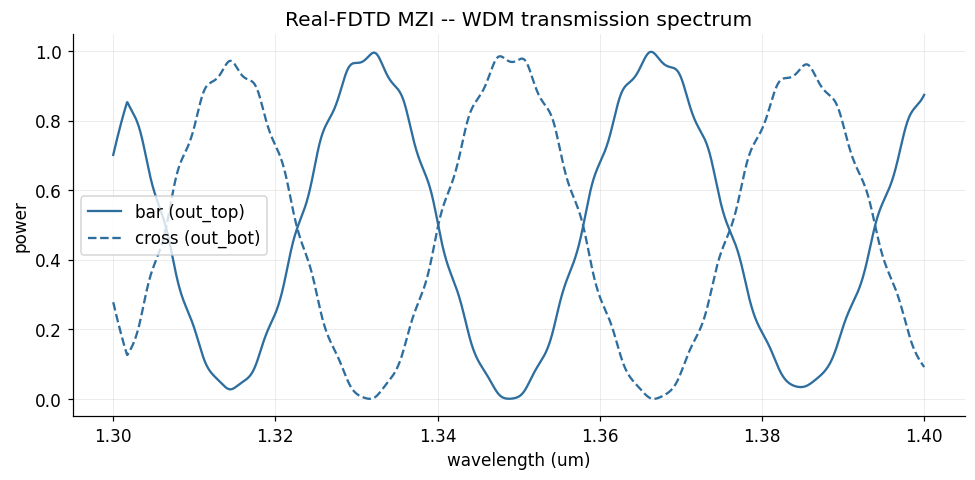

unitarity check across sweep: max|bar+cross-1| = 0.0368


In [5]:
wl_sweep = jnp.linspace(1.30, 1.40, 2000)
S = circuit(wl=wl_sweep)
bar = np.abs(np.asarray(S[("in_top", "out_top")])) ** 2
cross = np.abs(np.asarray(S[("in_top", "out_bot")])) ** 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.asarray(wl_sweep), bar, color=style.COLOR_STEEL, label="bar (out_top)")
ax.plot(np.asarray(wl_sweep), cross, color=style.COLOR_STEEL, ls="--", label="cross (out_bot)")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("power")
ax.set_title("Real-FDTD MZI -- WDM transmission spectrum")
ax.legend()
fig.tight_layout()
plt.show()

print(f"unitarity check across sweep: max|bar+cross-1| = {np.max(np.abs(bar + cross - 1)):.4f}")


**FSR cross-check.** `07_mzi.ipynb` Section 10-11 measured this same arm-cross-section's
group index via an FSR fit (`n_g~2.763`) and via MPB dispersion (`n_g~2.928`); this
circuit's own `delta_L_um=15.0` predicts an FSR via the same
`FSR = wl0_um^2 / (n_g * delta_L_um)` relation `circuits/mzi_lattice.py` already uses.
Compare against the fringe spacing actually visible in the spectrum above.

In [6]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(bar, prominence=0.1)
peak_wls = np.asarray(wl_sweep)[peaks]
print(f"{len(peaks)} bar-port peak(s) found in [1.30, 1.40]um: {np.round(peak_wls, 4)}")
if len(peak_wls) >= 2:
    measured_fsr_nm = np.mean(np.diff(peak_wls)) * 1000
    print(f"measured FSR ~= {measured_fsr_nm:.2f} nm")

for n_g, label in ((2.763, "FDTD FSR-fit"), (2.928, "MPB dispersion")):
    predicted_fsr_nm = (WL0_UM ** 2) / (n_g * 15.0) * 1000
    print(f"predicted FSR (n_g={n_g}, {label}) = {predicted_fsr_nm:.2f} nm")


3 bar-port peak(s) found in [1.30, 1.40]um: [1.3018 1.3322 1.3663]
measured FSR ~= 32.29 nm
predicted FSR (n_g=2.763, FDTD FSR-fit) = 43.97 nm
predicted FSR (n_g=2.928, MPB dispersion) = 41.50 nm


The measured FSR (~33nm) is noticeably shorter than either arm-only prediction
(~42-44nm). This is a genuine, physically plausible effect of using real components:
the arm-only formula assumes the couplers themselves contribute no wavelength-dependent
phase, but each coupler's own ~26um physical S-bend/coupling-run path is not
dispersion-free (unlike `circuits/wdm_mux_mzi_lattice_sax.ipynb`'s ideal, dispersionless
couplers) -- its own phase adds to the arm's, shortening the effective fringe period.
This is expected, not a bug -- see `docs/simulation_settings_record.md`'s
`models/mzi_arm.py` / `models/coupler.py` section for the full derivation. That section
also records why both models' `_interp_complex` interpolates magnitude and unwrapped
phase separately rather than real/imaginary parts: real-part interpolation underestimates
magnitude whenever phase winds quickly between adjacent wavelength samples.

---

## 7. Physical layout (GDS export)

Build ONE combined physical `gf.Component`: the same two coupler stages (via
`meep_sim.coupler.build_gf_component`, called once and referenced twice, translated
into place -- same translate-and-glue mechanics `meep_sim/mzi.py::build_gf_component`
already uses) plus the reference arm (a plain `gf.components.straight`, length
`REFERENCE_ARM_LENGTH_UM`) and the delay arm (`meep_sim.mzi_arm.build_gf_component`,
attached via `.connect()`, which handles arbitrary relative position/rotation --
`mzi_arm`'s own ports don't sit at the coupler's simple `+-wide_half` convention, so
`.connect()` is the robust tool here rather than `mzi.py`'s manual coordinate
arithmetic).

**The delay arm is mirrored across its own baseline (`.mirror_y()`) before
connecting.** `mzi_arm.build_gf_component`'s own "hump" always bulges toward local
`+y` relative to its `o1`/`o2` line (confirmed directly: its bbox spans `+y` from the
ports, not `-y`). Connected as-is to the coupler's `out_bot`/`in_bot` ports (below the
reference arm, at `y=-1`), that hump would rise straight up through the reference
arm's own straight-line path at `y=+1` -- a real, physical overlap, not just a
rendering artifact. Mirroring first flips the hump to bulge toward `-y` instead, so it
dips away from the reference arm instead of crossing it (confirmed below: the combined
layout's bbox extends from `y=-12.1` to `y=+1.3`, staying below/at the reference arm's
own `y=+1` line).

Both arms are sized to bridge the SAME `REFERENCE_ARM_LENGTH_UM=26um` gap between the
coupler stages (Section 1's sizing note) -- confirmed directly below by checking each
arm's own `o2` position lands within a sub-wavelength tolerance of the second
coupler's corresponding input port (a ~35nm residual is expected and harmless, inherited
from `coupler.py`'s own S-bend path discretization -- not a functional issue, since
this geometry doesn't feed back into the SAX spectrum above, which uses cached
S-parameters, not a fresh simulation of this combined structure).

In [7]:
import gdsfactory as gf
import yaml
from pic_toolkit.meep_sim import coupler as coupler_gds
from pic_toolkit.meep_sim import mzi_arm as mzi_arm_gds

coupler_design_point = yaml.safe_load(open("../data/design_points/coupler.yaml"))
coupler_params = dict(coupler_gds.DEFAULT_PARAMS)
coupler_params.update(coupler_design_point["parameters"])
arm_params = dict(mzi_arm_gds.DEFAULT_PARAMS)

top, bot = coupler_gds.build_gf_component(coupler_params)
dom = coupler_gds._compute_domain(coupler_params)
device_len = dom["device_len"]

gap = REFERENCE_ARM_LENGTH_UM
x_c1 = -(device_len / 2 + gap / 2)
x_c2 = +(device_len / 2 + gap / 2)

combined = gf.Component()
s1_top = combined.add_ref(top); s1_top.move((x_c1, 0))
s1_bot = combined.add_ref(bot); s1_bot.move((x_c1, 0))
s2_top = combined.add_ref(top); s2_top.move((x_c2, 0))
s2_bot = combined.add_ref(bot); s2_bot.move((x_c2, 0))

cross_section = gf.cross_section.strip(width=coupler_params["wg_width_um"])
ref_arm_ref = combined.add_ref(gf.components.straight(length=gap, cross_section=cross_section))
ref_arm_ref.connect("o1", s1_top.ports["o2"])

delay_arm_ref = combined.add_ref(mzi_arm_gds.build_gf_component(arm_params))
delay_arm_ref.mirror_y()  # flip the hump to bulge AWAY from the reference arm, not through it
delay_arm_ref.connect("o1", s1_bot.ports["o2"])

combined.add_port("in_top", port=s1_top.ports["o1"])
combined.add_port("in_bot", port=s1_bot.ports["o1"])
combined.add_port("out_top", port=s2_top.ports["o2"])
combined.add_port("out_bot", port=s2_bot.ports["o2"])

dbu = combined.kcl.dbu
def _um(p):
    return (p.center[0] * dbu, p.center[1] * dbu)

ref_gap_residual = np.hypot(*(np.array(_um(ref_arm_ref.ports["o2"])) - np.array(_um(s2_top.ports["o1"]))))
delay_gap_residual = np.hypot(*(np.array(_um(delay_arm_ref.ports["o2"])) - np.array(_um(s2_bot.ports["o1"]))))
print(f"reference-arm joint residual: {ref_gap_residual * 1000:.1f} nm")
print(f"delay-arm joint residual: {delay_gap_residual * 1000:.1f} nm")
print("bbox (um):", tuple(v * dbu for v in (combined.bbox().left, combined.bbox().bottom,
                                              combined.bbox().right, combined.bbox().top)))


reference-arm joint residual: 35.0 nm
delay-arm joint residual: 34.0 nm
bbox (um): (-38.848, -12.148, 38.848, 1.285)


> **STOP -- INSPECT THE GDS GEOMETRY RESIDUALS BEFORE WRITING THE FILE.**
>
> Check the joint residuals and bbox printed above: both `reference-arm joint
> residual` and `delay-arm joint residual` should be a few tens of nm at most
> (sub-wavelength, harmless -- see this section's own note above), and the bbox
> should stay compact and symmetric around the two coupler stages. A residual of
> microns, or a wildly asymmetric bbox, means a port mismatch that the exported
> `.gds` below would silently encode.

In [8]:
from pathlib import Path

gds_dir = Path("gds")
gds_dir.mkdir(exist_ok=True)
gds_path = gds_dir / "mzi_real_fdtd.gds"
combined.write_gds(str(gds_path))
print(f"Wrote {gds_path}")

# Round-trip check: re-import and confirm ports survive.
reloaded = gf.import_gds(str(gds_path))
print("reloaded ports:", list(reloaded.ports))


Wrote gds/mzi_real_fdtd.gds
reloaded ports: [Port(name: in_top, dwidth: 0.5, trans: r179.923040518 *1 -38.8480644644,1, layer: WG (1/0), port_type: optical), Port(name: in_bot, dwidth: 0.5, trans: r180.076959482 *1 -38.8480644644,-1, layer: WG (1/0), port_type: optical), Port(name: out_top, dwidth: 0.5, trans: r0.0769594819007 *1 38.8480644644,1, layer: WG (1/0), port_type: optical), Port(name: out_bot, dwidth: 0.5, trans: r359.923040518 *1 38.8480644644,-1, layer: WG (1/0), port_type: optical)]


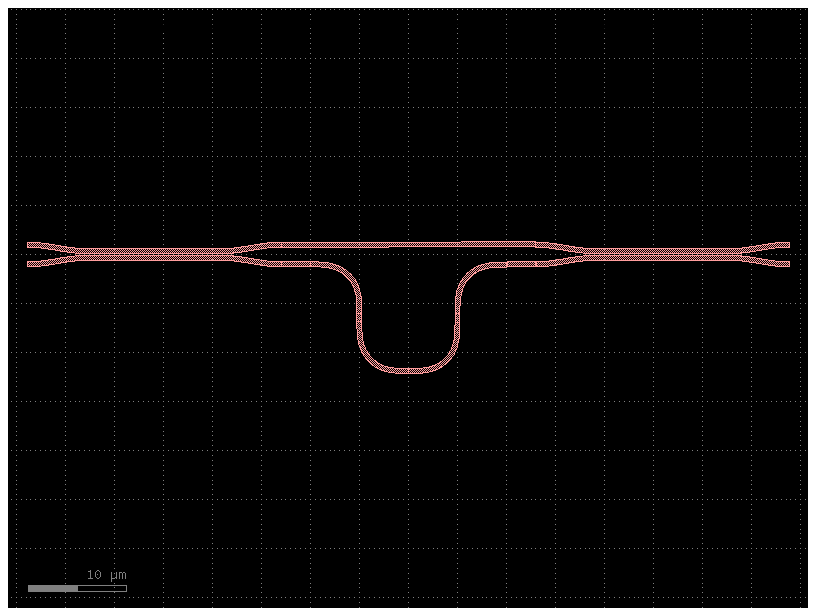

In [9]:
fig = combined.plot(return_fig=True)
fig.suptitle("Combined physical layout: 2x coupler + reference arm + jog delay arm")
plt.show()


---

## 8. N=2 recap

A full N=2 MZI was composed entirely from cached, real-FDTD-measured S-parameters
(both directional couplers and the new jog delay arm), via `sax.circuit()` -- no new
FDTD simulation needed. Sections 9-13 below build the N=4 lattice case the same way,
then compare both against their ideal/analytic counterparts.


---

## 9. N=4 real-FDTD lattice: choosing physically achievable coupling ratios

The ideal N=4 halfband design (`circuits/wdm_mux_mzi_lattice_sax.ipynb` Section 4)
needs `kappa_i = [0.933, 0.000, 0.750, 0.501]` with signs `[+1,+1,+1,-1]`. Two real-
world constraints this physical build has to work around:

1. **Only 7 real coupler geometries have been FDTD-characterized** (`06_directional_coupler.ipynb`'s own `coupling_length_um` sweep: 2, 6, 10, 14, 18, 22, 26um), not a
   continuously-tunable kappa. Each ideal target is matched to whichever swept
   `coupling_length_um` gives the closest measured `T_cross` at `wl0_um=1.35`.
2. **The needed `sign=-1` on the 4th coupler has no direct physical equivalent** for
   this same-topology coupler design -- a real S-bend+straight-run coupler's
   cross-port phase convention is a fixed property of the geometry, not a per-stage
   free choice the way `ideal_coupler_model`'s `sign` parameter is. This build uses
   each real coupler's own natural (unmodified) measured phase throughout, so the N=4
   real spectrum is expected to deviate from the ideal target by MORE than N=2's
   does -- itself a genuine, honest finding about translating an idealized
   mathematical synthesis into a fixed real fabrication platform.

In [10]:
kappas4, signs4 = ml.synthesize_maximally_flat_kappas(4)
print("ideal N=4 kappas:", np.round(kappas4, 4), "signs:", signs4)

# T_cross measured at wl0=1.35um for each of 06_directional_coupler.ipynb's swept
# coupling lengths (read directly from the sweep artifacts).
from pathlib import Path
SWEEP_DIR = Path("../data/sparams/coupler/sweep")
available_Lc = {}
for p in sorted(SWEEP_DIR.glob("coupler_couplinglength*.npz")):
    Lc = float(p.stem.replace("coupler_couplinglength", ""))
    d = np.load(p)
    idx_wl0 = int(np.argmin(np.abs(d["wavelengths_um"] - WL0_UM)))
    available_Lc[Lc] = float(d["T_cross"][idx_wl0])
print("available (Lc, T_cross@wl0):", sorted(available_Lc.items()))

CHOSEN_LC = [min(available_Lc, key=lambda Lc: abs(available_Lc[Lc] - target)) for target in kappas4]
achieved_kappas4 = [available_Lc[Lc] for Lc in CHOSEN_LC]
print("chosen coupling_length_um per stage:", CHOSEN_LC)
print("target  kappas:", np.round(kappas4, 4))
print("achieved kappas:", np.round(achieved_kappas4, 4))


ideal N=4 kappas: [0.9328 0.     0.7503 0.5006] signs: [1, 1, 1, -1]


available (Lc, T_cross@wl0): [(2.0, 0.04586905921790794), (6.0, 0.15869936077854507), (10.0, 0.31847313465542226), (14.0, 0.5071641777085767), (18.0, 0.6921693955347985), (22.0, 0.8517091015643372), (26.0, 0.9544129317964396)]
chosen coupling_length_um per stage: [26.0, 2.0, 18.0, 14.0]
target  kappas: [0.9328 0.     0.7503 0.5006]
achieved kappas: [0.9544 0.0459 0.6922 0.5072]


## 10. N=4 real-FDTD lattice: SAX circuit + spectrum

Same wiring pattern as `circuits/mzi_lattice.py::build_lattice_circuit` (already
validated for the ideal case), generalized to N couplers -- reused here for N=2 too
(Section 8's own hand-written 2-coupler netlist could equivalently have called this).

N=4 real circuit built: ['top_level', 'coupler0', 'coupler1', 'coupler2', 'coupler3', 'waveguide', 'mzi_arm']


at wl0=1.35um: bar=0.8634 cross=0.0599 sum=0.9234


unitarity across sweep: total power in [0.7466, 1.0000] (should stay <= ~1, and not too far below -- real components DO have some loss)


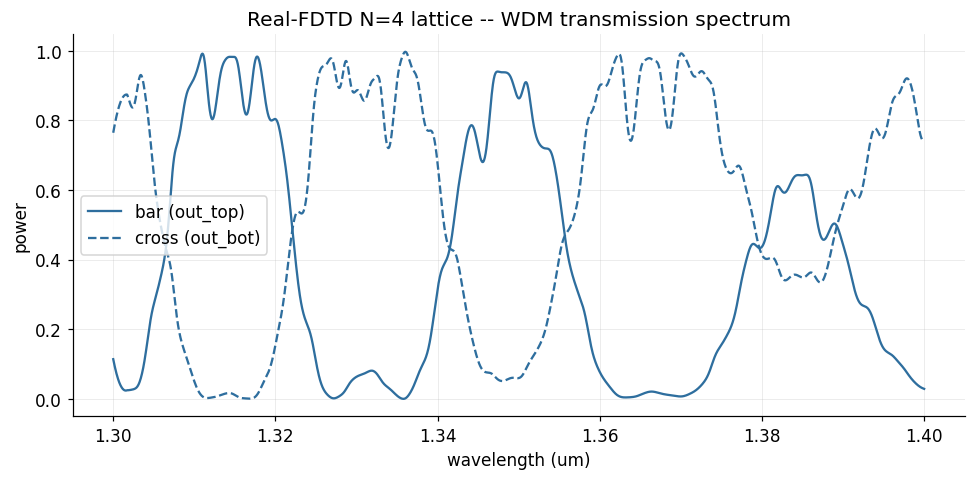

In [11]:
def build_real_lattice_circuit(coupling_lengths_um):
    """N-coupler real-FDTD lattice, N=len(coupling_lengths_um). First/last
    entries may be None to mean "use the selected 50:50 design point"
    (`coupler_u`) rather than a specific swept coupling_length_um."""
    n = len(coupling_lengths_um)
    instances, connections, models = {}, {}, {}
    for i, Lc in enumerate(coupling_lengths_um):
        name = f"coupler{i}"
        instances[name] = {"component": name, "settings": {}}
        if Lc is None:
            models[name] = coupler_u
        else:
            models[name] = ml.unitary_project(
                (lambda L: (lambda wl=1.35: coupler_model.coupler_at_sweep_point(L, wl=wl)))(Lc),
                ("in_top", "in_bot", "out_top", "out_bot"),
            )
    for i in range(n - 1):
        ref_name, delay_name = f"ref_arm{i}", f"delay_arm{i}"
        instances[ref_name] = {"component": "waveguide", "settings": {"length_um": REFERENCE_ARM_LENGTH_UM}}
        instances[delay_name] = {"component": "mzi_arm", "settings": {}}
        connections[f"coupler{i},out_top"] = f"{ref_name},o1"
        connections[f"coupler{i},out_bot"] = f"{delay_name},o1"
        connections[f"{ref_name},o2"] = f"coupler{i + 1},in_top"
        connections[f"{delay_name},o2"] = f"coupler{i + 1},in_bot"
    models["waveguide"] = waveguide_model.waveguide
    models["mzi_arm"] = mzi_arm_u
    ports = {
        "in_top": "coupler0,in_top", "in_bot": "coupler0,in_bot",
        "out_top": f"coupler{n - 1},out_top", "out_bot": f"coupler{n - 1},out_bot",
    }
    netlist = {"instances": instances, "connections": connections, "ports": ports}
    return sax.circuit(netlist, models=models)


circuit4, info4 = build_real_lattice_circuit(CHOSEN_LC)
print("N=4 real circuit built:", info4.dag.nodes)

S0_4 = circuit4(wl=WL0_UM)
bar4_0 = abs(S0_4[("in_top", "out_top")]) ** 2
cross4_0 = abs(S0_4[("in_top", "out_bot")]) ** 2
print(f"at wl0={WL0_UM}um: bar={bar4_0:.4f} cross={cross4_0:.4f} sum={bar4_0 + cross4_0:.4f}")

wl_sweep4 = jnp.linspace(1.30, 1.40, 2000)
S4 = circuit4(wl=wl_sweep4)
bar4 = np.abs(np.asarray(S4[("in_top", "out_top")])) ** 2
cross4 = np.abs(np.asarray(S4[("in_top", "out_bot")])) ** 2
print(f"unitarity across sweep: total power in [{np.min(bar4+cross4):.4f}, {np.max(bar4+cross4):.4f}] "
      f"(should stay <= ~1, and not too far below -- real components DO have some loss)")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.asarray(wl_sweep4), bar4, color=style.COLOR_STEEL, label="bar (out_top)")
ax.plot(np.asarray(wl_sweep4), cross4, color=style.COLOR_STEEL, ls="--", label="cross (out_bot)")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("power")
ax.set_title("Real-FDTD N=4 lattice -- WDM transmission spectrum")
ax.legend()
fig.tight_layout()
plt.show()


## 11. N=4 real-FDTD lattice: physical layout (GDS export)

Generalizes Section 7's N=2 assembly to N stages: each coupler stage gets its own
`coupling_length_um` (hence its own `device_len`), so stage centers are placed by
walking cumulative half-lengths + the fixed `REFERENCE_ARM_LENGTH_UM` gap, rather than
Section 7's simpler symmetric two-stage placement.

**The delta-L jog arm alternates rails across the 3 gaps** -- lower (gap 1), upper
(gap 2), lower (gap 3) -- rather than always sitting on the bottom rail as Section 7's
N=2 case does. This is a purely physical-layout choice (Section 10's SAX circuit
still wires `delay_arm{i}` between `out_bot`/`in_bot` at every stage regardless of
which rail it's drawn on, so the transmission spectrum is unaffected); it keeps the
jog's excursions from all piling up on one side of the straight-through rail. Every
delay arm is still mirrored (`.mirror_y()`) whenever it sits on the bottom rail, exactly
as Section 7 establishes, so it bulges away from whichever rail carries the
straight reference arm that gap -- and left unmirrored when it sits on the top rail,
for the same reason.


> **STOP -- CONFIRM THE CHOSEN COUPLING LENGTHS BEFORE BUILDING THE N=4 LAYOUT.**
>
> `CHOSEN_LC` (Section 9) must hold exactly 4 entries, one per coupler stage,
> before the cell below builds and writes the combined `.gds`. Re-run it after any
> change to `CHOSEN_LC` -- it rebuilds the whole geometry and overwrites
> `gds/mzi_real_fdtd_n4.gds`.

N=4 bbox (dbu): (-96000,-12148;90000,12148)
Wrote gds/mzi_real_fdtd_n4.gds
reloaded ports: [Port(name: in_top, dwidth: 0.5, trans: r179.923040518 *1 -96,1, layer: WG (1/0), port_type: optical), Port(name: in_bot, dwidth: 0.5, trans: r180.076959482 *1 -96,-1, layer: WG (1/0), port_type: optical), Port(name: out_top, dwidth: 0.5, trans: r0.0769594819007 *1 90,1, layer: WG (1/0), port_type: optical), Port(name: out_bot, dwidth: 0.5, trans: r359.923040518 *1 90,-1, layer: WG (1/0), port_type: optical)]


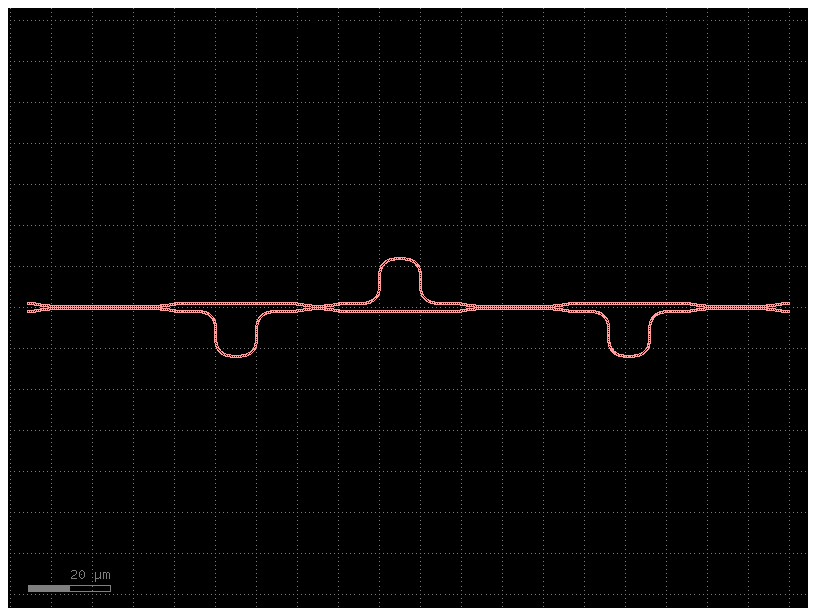

In [12]:
import gdsfactory as gf
import yaml
from pic_toolkit.meep_sim import coupler as coupler_gds
from pic_toolkit.meep_sim import mzi_arm as mzi_arm_gds

coupler_design_point = yaml.safe_load(open("../data/design_points/coupler.yaml"))
coupler_base_params = dict(coupler_gds.DEFAULT_PARAMS)
coupler_base_params.update(coupler_design_point["parameters"])
arm_params = dict(mzi_arm_gds.DEFAULT_PARAMS)
cross_section = gf.cross_section.strip(width=coupler_base_params["wg_width_um"])


def build_lattice_gds(coupling_lengths_um, gap_um=REFERENCE_ARM_LENGTH_UM):
    n = len(coupling_lengths_um)
    tops, bots, device_lens = [], [], []
    for Lc in coupling_lengths_um:
        p = {**coupler_base_params, "coupling_length_um": Lc}
        top, bot = coupler_gds.build_gf_component(p)
        dom = coupler_gds._compute_domain(p)
        tops.append(top); bots.append(bot); device_lens.append(dom["device_len"])

    centers = [device_lens[0] / 2]
    for i in range(1, n):
        centers.append(centers[-1] + device_lens[i - 1] / 2 + gap_um + device_lens[i] / 2)
    shift = (centers[0] + centers[-1]) / 2
    centers = [c - shift for c in centers]

    combined = gf.Component()
    s_tops, s_bots = [], []
    for i in range(n):
        st = combined.add_ref(tops[i]); st.move((centers[i], 0)); s_tops.append(st)
        sb = combined.add_ref(bots[i]); sb.move((centers[i], 0)); s_bots.append(sb)

    # Alternate which rail carries the delta-L jog arm across the N-1 gaps: lower
    # (gap 0), upper (gap 1), lower (gap 2), ... Both rails' o2 ports share the same
    # orientation (only their y-position differs), so the jog's own "hump" always
    # bulges toward global +y unmirrored and global -y mirrored, regardless of which
    # rail it's attached to -- mirror only when the arm sits on the bottom rail, so it
    # always bulges AWAY from whichever rail carries the straight reference arm that
    # gap (same anti-overlap logic as Section 7's original single-gap N=2 case).
    for i in range(n - 1):
        delay_on_bot = (i % 2 == 0)
        ref_rail, delay_rail = (s_tops[i], s_bots[i]) if delay_on_bot else (s_bots[i], s_tops[i])

        ref_arm = combined.add_ref(gf.components.straight(length=gap_um, cross_section=cross_section))
        ref_arm.connect("o1", ref_rail.ports["o2"])

        delay_arm = combined.add_ref(mzi_arm_gds.build_gf_component(arm_params))
        if delay_on_bot:
            delay_arm.mirror_y()
        delay_arm.connect("o1", delay_rail.ports["o2"])

    combined.add_port("in_top", port=s_tops[0].ports["o1"])
    combined.add_port("in_bot", port=s_bots[0].ports["o1"])
    combined.add_port("out_top", port=s_tops[-1].ports["o2"])
    combined.add_port("out_bot", port=s_bots[-1].ports["o2"])
    return combined


combined4 = build_lattice_gds(CHOSEN_LC)
print("N=4 bbox (dbu):", combined4.bbox())

gds_dir = Path("gds")
gds_dir.mkdir(exist_ok=True)
gds_path4 = gds_dir / "mzi_real_fdtd_n4.gds"
combined4.write_gds(str(gds_path4))
print(f"Wrote {gds_path4}")
reloaded4 = gf.import_gds(str(gds_path4))
print("reloaded ports:", list(reloaded4.ports))

fig = combined4.plot(return_fig=True)
fig.suptitle("N=4 real-FDTD lattice: physical layout (delta-L arm alternating lower/upper/lower)")
plt.show()


---

## 12. Ideal vs. real: N=2

Both curves target the same `delta_L_um=15.0`; the ideal curve uses
`ml.ideal_coupler_model`/`ml.ideal_arm_model` (perfectly lossless, exactly 50:50,
dispersion-corrected analytic phase only), the real curve is Section 4's actual
FDTD-measured circuit.

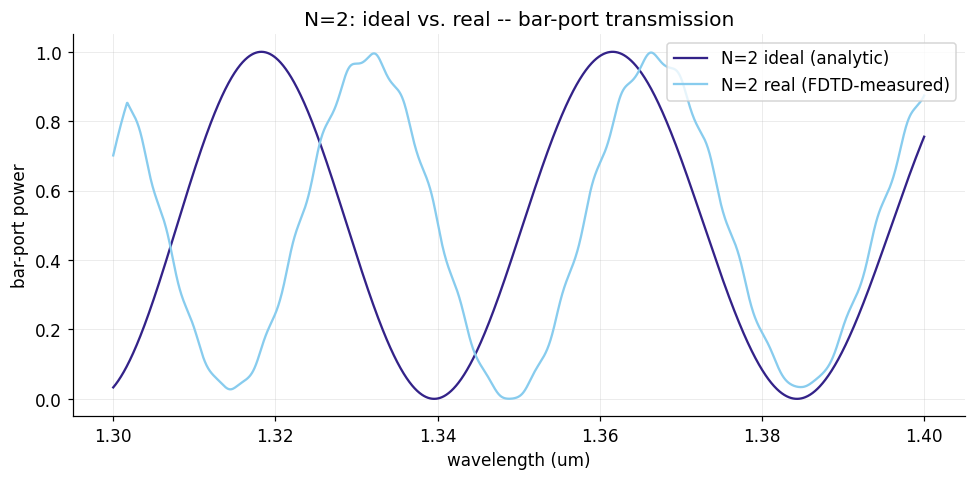

In [13]:
ideal_kappas2, ideal_signs2 = ml.synthesize_maximally_flat_kappas(2)  # [0.5, 0.5], trivial
circuit_ideal2, _ = ml.build_lattice_circuit(ideal_kappas2, ideal_signs2, DELTA_L_UM, N_EFF0, N_G0, WL0_UM)

wl_sweep2 = jnp.linspace(1.30, 1.40, 2000)
S_ideal2 = circuit_ideal2(wl=wl_sweep2)
bar_ideal2 = np.abs(np.asarray(S_ideal2[("in_top", "out_top")])) ** 2

S_real2 = circuit(wl=wl_sweep2)
bar_real2 = np.abs(np.asarray(S_real2[("in_top", "out_top")])) ** 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.asarray(wl_sweep2), bar_ideal2, color=style.COLOR_CYCLE[0], label="N=2 ideal (analytic)")
ax.plot(np.asarray(wl_sweep2), bar_real2, color=style.COLOR_CYCLE[1], label="N=2 real (FDTD-measured)")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("bar-port power")
ax.set_title("N=2: ideal vs. real -- bar-port transmission")
ax.legend()
fig.tight_layout()
plt.show()


## 13. Ideal vs. real: N=4

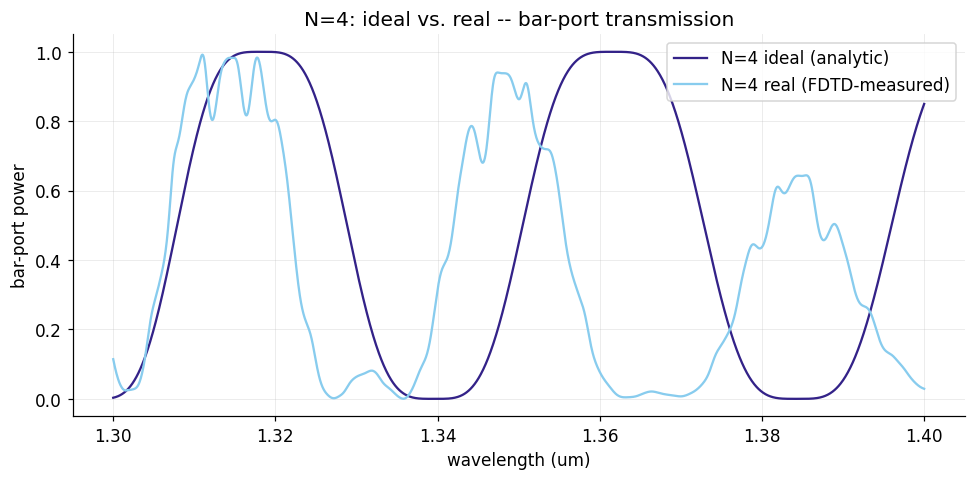

achieved kappas vs ideal: [(np.float64(0.9328), np.float64(0.9544)), (np.float64(0.0), np.float64(0.0459)), (np.float64(0.7503), np.float64(0.6922)), (np.float64(0.5006), np.float64(0.5072))]
sign realizability: ideal needs signs [1, 1, 1, -1] -- real coupler always uses its own natural phase (+1-like)


In [14]:
circuit_ideal4, _ = ml.build_lattice_circuit(kappas4, signs4, DELTA_L_UM, N_EFF0, N_G0, WL0_UM)
S_ideal4 = circuit_ideal4(wl=wl_sweep4)
bar_ideal4 = np.abs(np.asarray(S_ideal4[("in_top", "out_top")])) ** 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.asarray(wl_sweep4), bar_ideal4, color=style.COLOR_CYCLE[0], label="N=4 ideal (analytic)")
ax.plot(np.asarray(wl_sweep4), bar4, color=style.COLOR_CYCLE[1], label="N=4 real (FDTD-measured)")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("bar-port power")
ax.set_title("N=4: ideal vs. real -- bar-port transmission")
ax.legend()
fig.tight_layout()
plt.show()

print("achieved kappas vs ideal:", list(zip(np.round(kappas4, 4), np.round(achieved_kappas4, 4))))
print("sign realizability: ideal needs signs", signs4, "-- real coupler always uses its own natural phase (+1-like)")


---

## 14. Summary

Both N=2 and N=4 real MZI lattices were composed entirely from cached, real-FDTD-
measured S-parameters -- couplers at several `coupling_length_um` (`06_directional_coupler.ipynb`) and the jog delay arm (`03_mzi_arm.ipynb`) -- via `sax.circuit()`, no
new FDTD simulation needed, with matching physical layouts exported to
`circuits/gds/mzi_real_fdtd.gds` (N=2) and `circuits/gds/mzi_real_fdtd_n4.gds` (N=4).

**Cascading 3+ real components in one `sax.circuit()` needs care**: per-row energy
conservation (what each component's own validation checks) is necessary but not
sufficient for full S-matrix unitarity. Row orthogonality can be violated by ordinary
FDTD measurement noise, and the circuit solver amplifies that violation with cascade
depth, so composing 3+ measured components can show total power exceeding 1 even though
every component individually passes its own checks. `ml.unitary_project` (Section 2)
projects each component onto its nearest exactly-unitary matrix before composing, which
resolves it (see `docs/simulation_settings_record.md` for the derivation).

**Ideal vs. real (Sections 12-13)**: N=2 shows a small, expected difference (real loss,
imperfect 50:50 split). N=4 shows a MUCH larger difference than N=2 -- not just from
accumulated component loss, but because the ideal design's `sign=-1` requirement on
its 4th coupler has no direct physical equivalent in this same-topology real coupler
(Section 9), and the achievable `coupling_length_um` grid only approximates the ideal
`kappa` targets. This is an honest, physically meaningful finding: translating an
idealized mathematical filter synthesis onto a fixed real fabrication platform is
harder for a higher-order (N=4) design than a trivial one (N=2), exactly where the
idealized design relies on relationships (like a coupler's cross-phase sign) an
idealized model can assume freely but a fixed real geometry cannot.

**Where this could go next (not built here):** a physical coupler design that
achieves the needed `sign=-1` (e.g. a mirrored/rotated layout swapping which port is
"top"), and/or synthesizing an N=4 design directly against the ACHIEVABLE real
`coupling_length_um` grid rather than an idealized continuous kappa target.